# EDA — SpotGenTrack

Just poking around before I commit to any modeling. I want to check:
- what the lyrics look like (length, any weird formatting)
- valence/energy distribution — these will become my mood labels
- class balance after thresholding
- how big the "gap zone" is in the middle (I'm planning to drop it)

Dataset: SpotGenTrack. The `spotify_tracks.csv` file has lyrics + valence + energy all in one file, which is nice.

In [2]:
import sys
sys.path.insert(0, "..")  # so I can import from src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.preprocess import derive_mood_labels, is_gap_zone
from src.preprocess import VALENCE_LOW, VALENCE_HIGH, ENERGY_LOW, ENERGY_HIGH

## load

In [3]:
cols = ["id", "name", "artists_id", "lyrics", "valence", "energy", "danceability", "popularity"]
df = pd.read_csv("../SpotGenTrack/Data Sources/spotify_tracks.csv", usecols=cols, low_memory=False)
df.shape

(101939, 8)

In [4]:
df.head()

,artists_id,danceability,energy,id,lyrics,name,popularity,valence
0,['3mxJuHRn2ZWD5OofvJtDZY'],0.698,0.606,5qljLQuKnNJf4F4vfxQB0V,\r\n\r\nPerhaps I am bound to be restless\r\nA...,Blood,28.0,0.6220
1,['4xWMewm6CYMstu0sPgd9jJ'],0.719,0.308,3VAX2MJdmdqARLSU5hPMpm,\r\nYour Gods and my Gods-do you or I know whi...,The Ugly Duckling,31.0,0.5890
2,['3hYaK5FF3YAglCj5HZgBnP'],0.466,0.931,1L3YAhsEMrGVvCgDXj2TYn,"\r\n\r\nClosed off from love, I didn't need th...",Jimmy Launches His Own Range Of Greetings Cards,31.0,0.0850
3,['2KQsUB9DRBcJk17JWX1eXD'],0.719,0.126,6aCe9zzoZmCojX7bbgKKtf,"\r\nPAIN, n. An uncomfortable frame of mind th...",The Crime At Pickets Mill,14.0,0.5330
4,['3hYaK5FF3YAglCj5HZgBnP'],0.460,0.942,1Vo802A38tPFHmje1h91um,"\r\n\r\nClosed off from love, I didn't need th...",Setup + Punchline = Joke,32.0,0.0906


In [5]:
# what does a raw lyric actually look like?
print(df["lyrics"].iloc[0][:500])



Perhaps I am bound to be restless
Always yearning, never satisfied
Perhaps I'm aching for nothing
That words can't ever define

Was I happy in those moments
Or have I made it seem that way?
Was I back there tomorrow
Could feel as lacking as today?

But you in your golden hour
And you with your sweetest song
And you with your tender offerings
How could I ever do you wrong?

There's an unrest that keeps me marching
There's foolish hope that can be found
Something so true and l


The lyrics have Genius-style section headers (`[Chorus]`, `[Verse 1]`) and Windows line endings. Strip those in preprocessing later — for EDA we just care about lengths.

In [6]:
df.isna().sum()

artists_id      0
danceability    0
energy          0
id              0
lyrics          0
name            0
popularity      0
valence         0
dtype: int64

In [7]:
df.dtypes

artists_id       object
danceability    float64
energy          float64
id               object
lyrics           object
name             object
popularity      float64
valence         float64
dtype: object

## lyric length

In [8]:
df["word_count"] = df["lyrics"].str.split().map(len)
df["word_count"].describe()

count    101939.000000
mean        298.214363
std         825.988404
min           0.000000
25%         123.000000
50%         224.000000
75%         331.000000
max       38062.000000
Name: word_count, dtype: float64

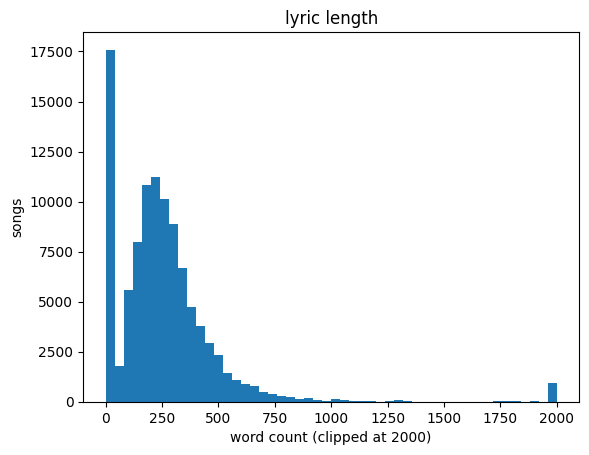

In [9]:
# there's a huge tail (max is way out there), so clipping for the plot
plt.hist(df["word_count"].clip(upper=2000), bins=50)
plt.xlabel("word count (clipped at 2000)")
plt.ylabel("songs")
plt.title("lyric length")
plt.savefig("../results/lyric_length_hist.png")
plt.show()

## Valence vs Energy

Russell's circumplex idea — two axes, positivity + intensity. We can cut this into 5 moods + a gap zone (see `src/preprocess.py` for the thresholds). Dashed lines show the cuts.

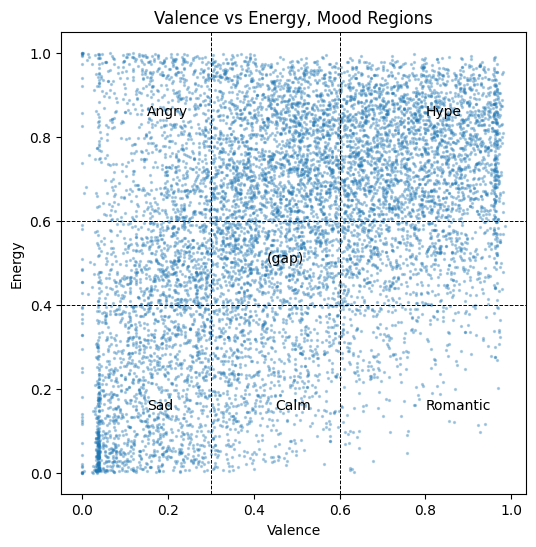

In [10]:
sample = df.sample(10000, random_state=42)  # plotting 100k points is too slow

plt.figure(figsize=(6, 6))
plt.scatter(sample["valence"], sample["energy"], s=2, alpha=0.3)

# threshold lines
for v in [VALENCE_LOW, VALENCE_HIGH]:
    plt.axvline(v, color="k", linestyle="--", linewidth=0.7)
for e in [ENERGY_LOW, ENERGY_HIGH]:
    plt.axhline(e, color="k", linestyle="--", linewidth=0.7)

# quadrant labels
plt.text(0.15, 0.85, "Angry")
plt.text(0.80, 0.85, "Hype")
plt.text(0.80, 0.15, "Romantic")
plt.text(0.15, 0.15, "Sad")
plt.text(0.45, 0.15, "Calm")
plt.text(0.43, 0.50, "(gap)")

plt.xlabel("Valence")
plt.ylabel("Energy")
plt.title("Valence vs Energy, Mood Regions")
plt.savefig("../results/valence_energy_scatter.png")
plt.show()

## Apply Mood Thresholds

In [11]:
labeled = derive_mood_labels(df)
labeled["mood"].value_counts(dropna=False)

mood
Hype        45824
Sad         19814
Romantic    10209
NaN          9121
Angry        8954
Calm         8017
Name: count, dtype: int64

In [12]:
# as percentages
(labeled["mood"].value_counts(dropna=False, normalize=True) * 100).round(1)

mood
Hype        45.0
Sad         19.4
Romantic    10.0
NaN          8.9
Angry        8.8
Calm         7.9
Name: proportion, dtype: float64

Hype is bigger than everything else (~45%) — any song with high energy ends up there. That's a skewed label distribution. I will use `class_weight='balanced'` later and track the macro-F1 delta.

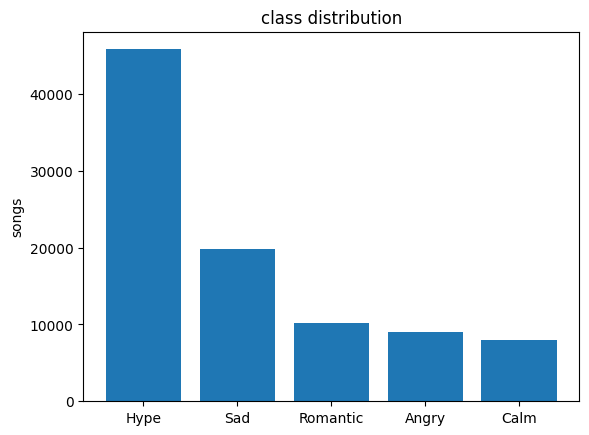

In [13]:
counts = labeled["mood"].value_counts()
plt.bar(counts.index, counts.values)
plt.title("class distribution")
plt.ylabel("songs")
plt.savefig("../results/class_distribution.png")
plt.show()

### Verify the Labels
The thresholds are arbitrary so I want to look at a few songs per class and see if they match intuition.

In [14]:
for m in ["Hype", "Sad", "Romantic", "Angry", "Calm"]:
    rows = labeled[labeled["mood"] == m].sample(3, random_state=1)
    print(f"--- {m} ---")
    for _, r in rows.iterrows():
        print(f"  {r['name']!r:<50} v={r['valence']:.2f} e={r['energy']:.2f}")
    print()

--- Hype ---
  'Ready Now'                                        v=0.65 e=0.82
  'Como hablar'                                      v=0.63 e=0.78
  'Fight Song'                                       v=0.83 e=0.90

--- Sad ---
  'Si Estuviésemos Juntos'                           v=0.16 e=0.59
  'Changed'                                          v=0.19 e=0.38
  'Stand Still'                                      v=0.16 e=0.44

--- Romantic ---
  'I Need A Dollar'                                  v=0.96 e=0.48
  'I Want Her - Remastered Single Version'           v=0.86 e=0.50
  "Amor Pa' Que"                                     v=0.83 e=0.55

--- Angry ---
  'Mesa 8'                                           v=0.28 e=0.82
  'We Got It - S.P.Y Remix'                          v=0.08 e=0.88
  'Divine'                                           v=0.29 e=0.77

--- Calm ---
  'Verbs 1'                                          v=0.49 e=0.08
  'Folge 4: Leo Lausemaus will nicht baden - Teil 5' v=0

## Gap Zone

In [15]:
gap = is_gap_zone(df).sum()
print(f"gap-zone: {gap} songs ({gap/len(df)*100:.1f}%)")

gap-zone: 9121 songs (8.9%)


~9% of the data. Not huge, but enough to add noise if I leave it in. Dropping it is my second preprocessing before/after experiment.

## Save

In [16]:
processed = labeled.dropna(subset=["mood"])
processed = processed[processed["word_count"] >= 20]  # super-short lyrics are usually noise/instrumentals
# TODO: is 20 the right floor? check per-class stats later

processed.to_csv("../data/processed/songs_labeled.csv", index=False)
print(f"saved {len(processed)} rows")
processed["mood"].value_counts()

saved 76595 rows


mood
Hype        41831
Sad         12513
Romantic     9000
Angry        6632
Calm         6619
Name: count, dtype: int64

## Summary

- lyrics + valence + energy are 100% populated
- big class imbalance — Hype is ~6x bigger than Calm
- gap zone ~9%, dropping makes sense
- some lyrics are very long (max was 38k words) so we need to truncate or look at these in preprocessing